# Years to Financial Independence: the surface, its sensitivities, and a 3D print

How many years until you are financially independent (FI), as a function of your **income** and your **expenses**? This notebook

1. derives the closed form for the years to FI and the three regions it splits into,
2. shows that every iso-year contour is a **straight line through one focal point**,
3. maps the sensitivities (how many years $1k more spending, $1k more income or 1% more return is worth), and
4. builds a **watertight, labeled STL** of the surface for 3D printing, with raised contour lines, raised lines for your own income and expenses, and debossed (or embossed) labels and axis text.

Edit the **Settings** cell and run all. Everything is in real (inflation-adjusted) dollars. The math is written up in Money Plot Labs Whitepaper 006, and the same model runs in the browser in the *FI Surface* tool.

## Settings

In [1]:
import datetime
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.colors import LightSource
from PIL import Image, ImageDraw, ImageFont

# ---- Your situation (real, inflation-adjusted dollars) ----
R  = 0.05          # real annual return
S  = 0.04          # safe withdrawal rate: FI number = expenses / S
P0 = 250_000       # portfolio today
YOU_INCOME, YOU_EXPENSES = 100_000, 60_000      # after-tax income, annual spending

# ---- Plot window ----
INCOME_RANGE  = (25_000, 200_000)       # about 1/3x to 2x your income (the web tool fits these)
EXPENSE_RANGE = (0, 120_000)
CAP_YEARS = 30     # the surface is a flat plateau at or beyond this many years (incl. "never")

# ---- 3D print (all sizes in mm) ----
PRINT = dict(
    R=R, S=S, P0=P0, cap_years=CAP_YEARS,
    income_range=INCOME_RANGE, expense_range=EXPENSE_RANGE,
    you_income=YOU_INCOME, you_expenses=YOU_EXPENSES,
    contour_years=[5, 10, 15, 20, 25, 30],          # raised iso-year lines
    income_step=25_000, expense_step=20_000,        # grid ridges + tick labels
    mm_per_10k=10, expense_mm_per_10k=None,         # size: mm per $10k/yr (None = same as income,
                                                    # so $1 of income and of spending are equally long)
    height_mm=60,                                   # surface height at the cap
    base_mm=2.4, lift_mm=1.0,                       # ledge thickness; plot sits 1 mm above it
    layer_mm=0.2, first_layer_mm=0.2,               # your slicer: contour tops, base, step and text
                                                    # depth land on layer boundaries (0 = off)
    margin_left=None, margin_right=None, margin_front=None, margin_back=None,   # ledges; None = fit the text
    cell_mm=0.25,                                   # grid resolution (letters are traced inside cells)
    contour_shape='shelf',                          # 'step' (raised, filled to the slope; one color),
                                                    # 'shelf' (level notch: an even accent line),
                                                    # 'none' (color only, e.g. year bands)
    # widths and text sizes for a 0.6 mm nozzle; for a 0.4 mm nozzle use 1.2 / 1.6 / 0.8 mm
    # line widths and 5 / 5.5 / 4.5 mm text
    contour_ridge=dict(width=1.4, height=1.0),      # shape width; a step's height
    contour_fill_mm=8,
    you_ridge=dict(width=1.8, height=1.4),
    grid_ridge=dict(width=1.2, height=0.5),
    label_gap=0.8,                                  # clearance between a label and any ridge
    text_mode='deboss', text_depth_mm=0.6,          # 'deboss' (cut in), 'emboss' (raised) or 'none'
    tick_text_mm=6, title_text_mm=6.5, inline_text_mm=5.5,
    # Base (ledge) labels: '' drops an item
    income_title='INCOME ($/YR)', expense_title='EXPENSES ($/YR)',
    caption=True, caption_text='',                  # caption_text '' = auto: month, portfolio, return, SWR
    caption_date=None,                              # e.g. 'OCT 2026'; None = this month (the dollars' month)
    you_label='YOU', tick_labels=True,              # prefix on your lines' labels; tick values on/off
)
BED_MM = (250, 210, 210)                            # printer build volume (Prusa MK3S+)
COLORS = dict(contours='lines', base_labels=True)   # filament swaps: contours 'none' | 'lines' | 'bands'
                                                    # (pair 'lines' with a shelf, 'bands' with none)
STL_PATH = 'fi_surface.stl'

## The model

| Symbol | Meaning |
|---|---|
| $I$ | annual income (after tax) |
| $X$ | annual expenses |
| $C = I - X$ | annual savings |
| $R$ | real annual return |
| $S$ | safe withdrawal rate |
| $P_0$ | portfolio today |
| $F = X/S$ | FI number |

Each year the portfolio grows and you add your savings: $P_n = P_{n-1}(1+R) + C$, so

$$P_n = P_0(1+R)^n + C\,\frac{(1+R)^n - 1}{R}.$$

Setting $P_n = F$ and solving for $n$:

$$n = \frac{\ln\!\big((F + C/R)\,/\,(P_0 + C/R)\big)}{\ln(1+R)}.$$

> **Fixed:** the original notes had $P_0/S$ in the denominator. It is $P_0$ (the code already used $P_0$).

**A form that never divides by zero.** Write $\text{gap} = F - P_0$ (how far you are from FI) and $u = R P_0 + C$ (how much the portfolio grows in year one). Then

$$n = \frac{\ln\!\left(1 + R\,\text{gap}/u\right)}{\ln(1+R)}, \qquad \lim_{R\to 0} n = \frac{\text{gap}}{u}.$$

This is exact at $I = X$ and $R \to 0$, which the original form is not.

**Three regions.**
* $\text{gap} \le 0$ ($X \le S P_0$): **already FI**, so $n = 0$. The original code returned negative years here.
* $u \le 0$ ($X \ge I + R P_0$): the portfolio is not growing, so you **never** get there. The original code returned NaN here, or 0 in the STL cells. That printed a cliff down to zero exactly where FI is hardest, which is wrong. Here it is a plateau at the cap instead.
* otherwise $n > 0$ is finite.

**Contours are straight lines.** $n = L$ is the same as $F = P_0(1+R)^L + C\,s_L$, where $s_L = ((1+R)^L - 1)/R$. That is linear in $I$ and $X$:

$$X = X^{star}* + m_L\,(I - I^{star}*), \qquad m_L = \frac{S s_L}{1 + S s_L}, \qquad (I^{star}*, X^{star}*) = \big(P_0(S - R),\; S P_0\big).$$

Every contour passes through the **focal point** $(I^{star}*, X^{star}*)$. That point is where you are exactly at FI ($X = SP_0$) while withdrawing exactly the portfolio's growth ($C = -RP_0$). The slope runs from 0 (the $n = 0$ line) to 1 (the "never" line $X = I + RP_0$). So **$n$ depends only on the direction from the focal point.**

**Sensitivities.** With $D = u + R\,\text{gap} = C + R F$ and $\rho = R/\ln(1+R)$ (which goes to 1 as $R \to 0$):

$$\frac{\partial n}{\partial I} = -\frac{\rho\,\text{gap}}{u D}, \qquad \frac{\partial n}{\partial X} = \frac{\rho}{D}\Big(\frac1S + \frac{\text{gap}}{u}\Big), \qquad \frac{\partial n / \partial X}{-\partial n / \partial I} = 1 + \frac{u}{S\,\text{gap}} = \frac{I - I^{star}*}{X - X^{star}*}.$$

A dollar of expenses always costs more time than a dollar of income buys back. It cuts your savings just like lost income does, and it also raises the FI number by $1/S$ dollars.

In [2]:
def years_to_fi(I, X, R, S, P0):
    """Years n until P_n reaches the FI number X/S, with P_n = P_{n-1}(1+R) + (I - X).

    Vectorized over I and X. Returns 0 where you are already FI (P0 >= X/S) and
    inf where the portfolio never gets there (it is not growing: R*P0 + I - X <= 0).
    Written as n = ln(1 + R*gap/u) / ln(1+R) so it is exact at I == X and as R -> 0.
    """
    I, X = np.broadcast_arrays(np.asarray(I, float), np.asarray(X, float))
    gap = X / S - P0            # how far below the FI number you are today
    u = R * P0 + (I - X)        # how much the portfolio grows in year one
    with np.errstate(divide='ignore', invalid='ignore'):
        n = np.log1p(R * gap / u) / np.log1p(R) if R > 0 else gap / u
    n = np.where(u > 0, n, np.inf)
    return np.where(gap <= 0, 0.0, n)


def fi_gradient(I, X, R, S, P0):
    """Analytic (dn/dI, dn/dX) in years per dollar; NaN outside the reachable region."""
    I, X = np.broadcast_arrays(np.asarray(I, float), np.asarray(X, float))
    gap = X / S - P0
    u = R * P0 + (I - X)
    D = u + R * gap                              # = (I - X) + R * X/S
    rho = R / np.log1p(R) if R > 0 else 1.0      # -> 1 as R -> 0
    ok = (gap > 0) & (u > 0)
    with np.errstate(divide='ignore', invalid='ignore'):
        dI = np.where(ok, -rho * gap / (u * D), np.nan)
        dX = np.where(ok, rho * (1 / S + gap / u) / D, np.nan)
    return dI, dX


def focal_point(R, S, P0):
    """(I*, X*): every iso-year contour is a straight line through this point."""
    return P0 * (S - R), S * P0


def contour_slope(L, R, S):
    """dX/dI of the L-year contour: X = X* + slope * (I - I*). Between 0 (L = 0) and 1 (L -> inf)."""
    s = ((1 + R) ** L - 1) / R if R > 0 else L      # future value of $1/yr saved for L years
    return S * s / (1 + S * s)

### Checks
The closed form against a year-by-year simulation, the contour-line formula, and the analytic gradient against finite differences.

In [3]:
def simulate_years(I, X, R, S, P0, max_years=500):
    """Brute force: step P_n = P_{n-1}(1+R) + C, interpolating within the crossing year."""
    P, F = P0, X / S
    if P >= F:
        return 0.0
    for k in range(max_years):
        nxt = P * (1 + R) + (I - X)
        if nxt >= F:
            return k + (F - P) / (nxt - P)
        P = nxt
    return np.inf

# 1) closed form = recursion at whole years, and within a year of it in between
rng = np.random.default_rng(0)
for I, X in rng.uniform([20e3, 0], [300e3, 150e3], size=(500, 2)):
    n, sim = years_to_fi(I, X, R, S, P0), simulate_years(I, X, R, S, P0)
    assert (np.isinf(n) and (np.isinf(sim) or sim > 400)) or abs(n - sim) < 1, (I, X, n, sim)

# 2) contour lines: every point on X = X* + m_L (I - I*) has n = L
Is, Xs = focal_point(R, S, P0)
for L in [1, 5, 10, 25]:
    I = np.linspace(60e3, 300e3, 5)
    assert np.allclose(years_to_fi(I, Xs + contour_slope(L, R, S) * (I - Is), R, S, P0), L)

# 3) analytic gradient = finite differences
dI, dX = fi_gradient(YOU_INCOME, YOU_EXPENSES, R, S, P0)
h = 1.0
assert np.isclose(dI, (years_to_fi(YOU_INCOME + h, YOU_EXPENSES, R, S, P0) - years_to_fi(YOU_INCOME - h, YOU_EXPENSES, R, S, P0)) / (2 * h))
assert np.isclose(dX, (years_to_fi(YOU_INCOME, YOU_EXPENSES + h, R, S, P0) - years_to_fi(YOU_INCOME, YOU_EXPENSES - h, R, S, P0)) / (2 * h))

n_you = float(years_to_fi(YOU_INCOME, YOU_EXPENSES, R, S, P0))
dR = float(years_to_fi(YOU_INCOME, YOU_EXPENSES, R - 0.005, S, P0) - years_to_fi(YOU_INCOME, YOU_EXPENSES, R + 0.005, S, P0))
print(f'All checks pass. Focal point: income {Is:,.0f}, expenses {Xs:,.0f}')
print(f'You: {n_you:.2f} years to FI (FI number ${YOU_EXPENSES / S:,.0f})')
print(f'  -$1k/yr expenses  -> {dX * 1000:.3f} years sooner')
print(f'  +$1k/yr income    -> {-dI * 1000:.3f} years sooner   (a $1 cut in spending = ${dX / -dI:.2f} of raise)')
print(f'  +1% return        -> {dR:.3f} years sooner')

All checks pass. Focal point: income -2,500, expenses 10,000
You: 16.07 years to FI (FI number $1,500,000)
  -$1k/yr expenses  -> 0.435 years sooner
  +$1k/yr income    -> 0.212 years sooner   (a $1 cut in spending = $2.05 of raise)
  +1% return        -> 1.444 years sooner


## Sensitivity maps

Each map is per **$1k/yr** change (or per **1 percentage point** of return). Positive values are years *saved*. Dashed lines are the iso-year contours.

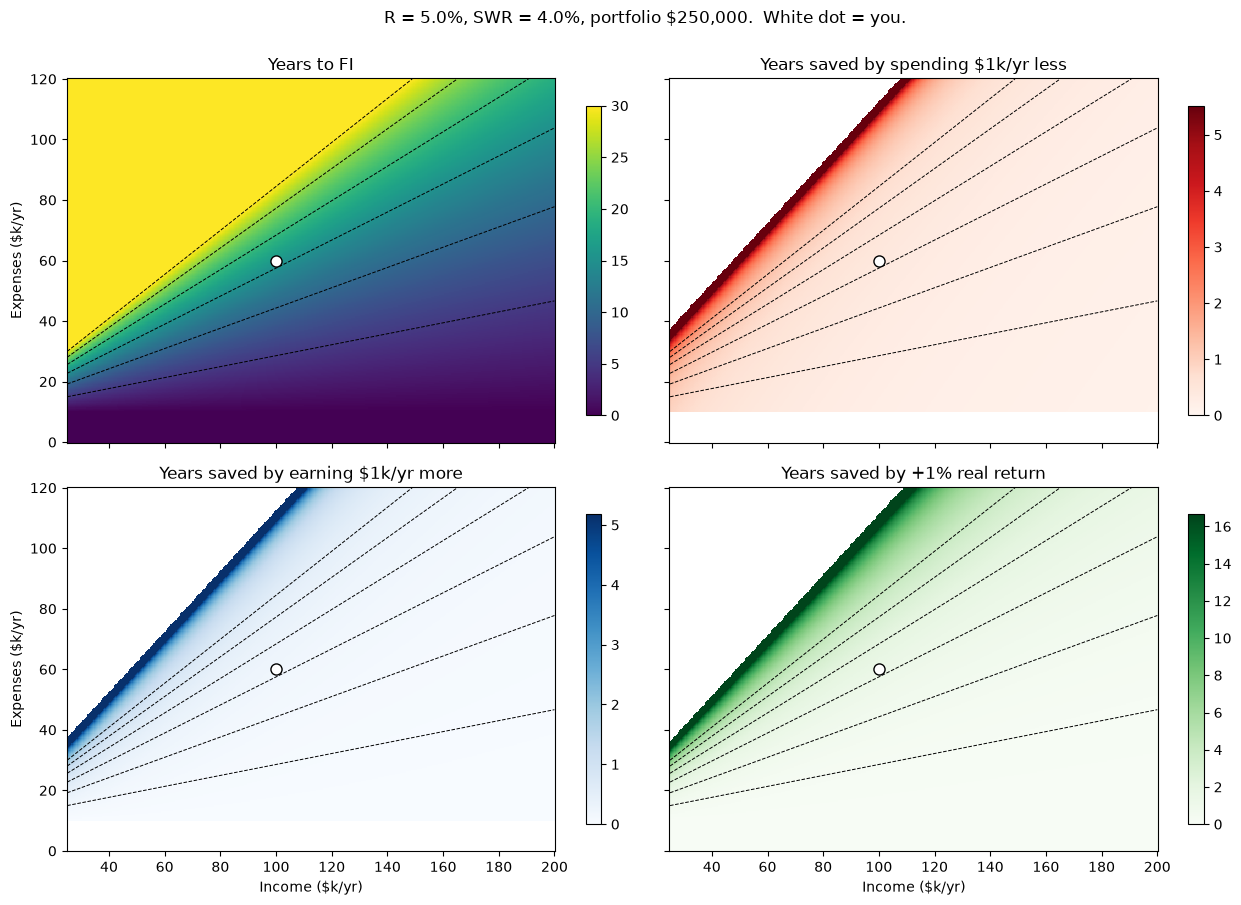

In [4]:
I_vals = np.linspace(*INCOME_RANGE, 400)
X_vals = np.linspace(*EXPENSE_RANGE, 300)
I_g, X_g = np.meshgrid(I_vals, X_vals)
n_g = years_to_fi(I_g, X_g, R, S, P0)
dI_g, dX_g = fi_gradient(I_g, X_g, R, S, P0)
h = 0.005
with np.errstate(invalid='ignore'):           # inf - inf in the "never" region
    dR_g = years_to_fi(I_g, X_g, R - h, S, P0) - years_to_fi(I_g, X_g, R + h, S, P0)
dR_g = np.where(np.isfinite(dR_g), dR_g, np.nan)

panels = [
    (np.minimum(n_g, CAP_YEARS), 'Years to FI', 'viridis'),
    (dX_g * 1000, 'Years saved by spending $1k/yr less', 'Reds'),
    (-dI_g * 1000, 'Years saved by earning $1k/yr more', 'Blues'),
    (dR_g, 'Years saved by +1% real return', 'Greens'),
]
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
for ax, (Z, title, cmap) in zip(axes.ravel(), panels):
    finite = Z[np.isfinite(Z)]
    vmax = np.percentile(finite, 98) if finite.size else 1
    im = ax.pcolormesh(I_vals / 1e3, X_vals / 1e3, Z, cmap=cmap, vmin=0, vmax=vmax, shading='auto')
    fig.colorbar(im, ax=ax, shrink=0.85)
    ax.contour(I_vals / 1e3, X_vals / 1e3, n_g, levels=PRINT['contour_years'], colors='k',
               linewidths=0.7, linestyles='--')
    ax.plot(YOU_INCOME / 1e3, YOU_EXPENSES / 1e3, 'o', ms=8, mfc='white', mec='k')
    ax.set_title(title)
for ax in axes[1]:
    ax.set_xlabel('Income ($k/yr)')
for ax in axes[:, 0]:
    ax.set_ylabel('Expenses ($k/yr)')
fig.suptitle(f'R = {R:.1%}, SWR = {S:.1%}, portfolio ${P0:,.0f}.  White dot = you.', y=1.0)
plt.tight_layout()
plt.show()

In [5]:
# Interactive 3D view (plotly ships with Colab; elsewhere: pip install plotly)
try:
    import plotly.graph_objects as go
except ImportError:
    print('plotly not installed: skipping the interactive view')
else:
    Zc = np.minimum(n_g, CAP_YEARS)
    fig = go.Figure(go.Surface(x=I_vals / 1e3, y=X_vals / 1e3, z=Zc, colorscale='Viridis',
                               contours_z=dict(show=True, start=5, end=CAP_YEARS, size=5, color='black'),
                               colorbar=dict(title='years')))
    j = np.argmin(abs(X_vals - YOU_EXPENSES)); i = np.argmin(abs(I_vals - YOU_INCOME))
    fig.add_scatter3d(x=I_vals / 1e3, y=np.full_like(I_vals, X_vals[j] / 1e3), z=Zc[j], mode='lines',
                      line=dict(color='red', width=6), name=f'Your expenses ${YOU_EXPENSES / 1e3:g}k')
    fig.add_scatter3d(x=np.full_like(X_vals, I_vals[i] / 1e3), y=X_vals / 1e3, z=Zc[:, i], mode='lines',
                      line=dict(color='blue', width=6), name=f'Your income ${YOU_INCOME / 1e3:g}k')
    fig.update_layout(scene=dict(xaxis_title='Income ($k)', yaxis_title='Expenses ($k)', zaxis_title='Years to FI'),
                      width=900, height=650, title='Years to FI')
    fig.show()

## 3D-print model

The surface becomes a heightmap on a regular millimeter grid, and then a closed STL:

* **Surface:** years to FI, capped at `CAP_YEARS`. Beyond the cap, including "never", the surface is a flat plateau.
* **Raised lines:** each one is a band within ±width/2 of a line, so every ridge prints at the same width whatever the slope. Each **iso-year contour is level and starts exactly on its line**, with its shape on the uphill side (`contour_shape`). A **step** is a cliff rising from the line to a flat top, filled uphill until it meets the slope. It reads by touch in one color. A **shelf** is a level notch cut at exactly the line's height; its floor takes an accent color as an even line. **None** adds nothing: with alternating year bands, the color change at the line's height *is* the line. All heights snap to layer boundaries. Lines that climb the slope (your income and expenses, the grid) have tops that follow the surface along the line and stay level across it. Ridge edges are sharp, with no in-between heights. The original code thresholded $|n - L| < 0.5$, which gave hairlines where the surface is steep and wide smears where it is flat. Contours are exact straight rays from the focal point. Your income and expense lines are taller. The light grid lines sit at every tick.
* **Labels:** **debossed** (cut in) or **embossed** (raised). The front and left ledges carry tick labels, the axis titles and a caption; all of these are editable in `PRINT` (`''` drops one), and the ledges resize to fit. Each raised line gets an inline label on its flattest free stretch, turned to run along the line and never upside down. Contour labels always sit on the uphill side, inside the band of years that starts at that line, so with year bands each band carries exactly one label. A contour with no room for an inline label is labeled on the back or right ledge where it leaves the plot.
* **Straight-walled, smooth text:** text is rasterized per grid cell, then averaged over the four cells around each grid point. Letters are traced where that field crosses ½ (marching squares), so the outline is placed inside each cell rather than stair-stepped along the grid. Letters get their own copy of the surface, moved by the text depth, joined to the rest by **vertical walls**, so every printed layer of a letter sits exactly on the one below. Contour shelves and steps get the same treatment: their edges are straight lines at any angle to the grid, traced exactly with vertical walls instead of stair-stepping.
* **Colors:** a single-nozzle printer changes filament between layers, and here height *is* years, so a swap at a contour's height colors exactly along that iso-year line. `color_plan` lists the Z heights for accent contour lines, alternating year bands, and accent base labels.
* **Flat plateau:** nothing rises above the cap height. Your income/expense lines and the grid level off into the plateau, since they mean nothing past the cap. The plateau's top layer marks the 30+ / never zone: it takes the accent in line mode and its own band in band mode.
* **Mesh:** two triangles per grid cell on top, a wall under every boundary edge, and a single fan for the flat bottom. Every edge is shared by exactly two oppositely wound triangles, so the mesh is watertight with outward normals. Where a wall would have no height (a shelf's edge on its own line, a step's top meeting the slope) its two vertices are merged, so there are no zero-area (degenerate) facets for the slicer to repair. The writer is binary STL, needs only numpy, and runs fully vectorized.

`cell_mm` sets the resolution. 0.25 mm gives about 0.9M triangles and a ~45 MB STL. 0.15 mm is finer still (~120 MB). Letter outlines are traced inside the cells either way.

In [6]:
# An Arial-like bold (as the web tool uses) where available: Arial on Windows/macOS, Liberation
# Sans on Linux/Colab; matplotlib's own DejaVu Sans (about 15% wider) otherwise.
FONT_PATH = fm.findfont(fm.FontProperties(family=['Arial', 'Liberation Sans', 'Helvetica', 'DejaVu Sans'], weight='bold'))


def k_label(v):
    """$ amount as a short tick label: 50000 -> '50k', 1250000 -> '1.25M'."""
    if v == 0:
        return '0'
    if abs(v) >= 1e6:
        return f'{v / 1e6:g}M'
    return f'{v / 1e3:g}k'


def ticks(lo, hi, step):
    return np.arange(np.ceil(lo / step) * step, hi + step / 2, step)


def readable(angle):
    """Fold an angle (degrees) into (-90, 90] so text never reads upside down."""
    angle = (angle + 180) % 360 - 180
    if angle > 90:
        angle -= 180
    elif angle <= -90:
        angle += 180
    return angle


TEXT_GAP = 1.5     # mm between the plot edge, tick labels and titles


def resolve_margins(p):
    """Ledge widths: given, or (None) just wide enough for the ledge text (16 / 8 mm at the defaults)."""
    p = dict(p)
    tick = TEXT_GAP + p['tick_text_mm'] if p['tick_labels'] else 0
    row = TEXT_GAP + p['title_text_mm'] if (p['income_title'] or p['caption']) else 0
    col = TEXT_GAP + p['title_text_mm'] if p['expense_title'] else 0
    auto = dict(margin_front=max(4, tick + row + 2.5), margin_left=max(4, tick + col + 2.5),
                margin_back=p['inline_text_mm'] + 3.5, margin_right=p['inline_text_mm'] + 3.5)
    for k, v in auto.items():
        if p.get(k) is None:
            p[k] = v
    return p


def snap_to_layer(v, p):
    """Nearest slicer layer boundary (first layer + k * layer) at or above the first layer."""
    if not p['layer_mm'] > 0:
        return v
    f = p['first_layer_mm'] or p['layer_mm']
    return round(max(f, f + np.floor((v - f) / p['layer_mm'] + 0.5) * p['layer_mm']), 6)


def layer_top(h, p):
    """Top of the printed layer that holds height h (layers: first, first + layer, ...)."""
    f = p['first_layer_mm'] or p['layer_mm']
    return f if h <= f else round(f + np.ceil((h - f) / p['layer_mm'] - 1e-6) * p['layer_mm'], 6)


def build_print_model(p):
    """Heightmap (mm) of the printable FI surface plus everything needed to label and mesh it."""
    p = resolve_margins(p)
    # size by scale: mm per $10k/yr, the same on both axes unless expense_mm_per_10k is set
    sx = p['mm_per_10k']
    sy = p.get('expense_mm_per_10k') or sx
    p['width_mm'] = (p['income_range'][1] - p['income_range'][0]) / 1e4 * sx
    p['depth_mm'] = (p['expense_range'][1] - p['expense_range'][0]) / 1e4 * sy
    # base, plot step and text depth are whole layers, so their edges land on layer boundaries
    p['base_mm'] = snap_to_layer(p['base_mm'], p)
    p['lift_mm'] = snap_to_layer(p['base_mm'] + p['lift_mm'], p) - p['base_mm']
    if p['layer_mm'] > 0:
        p['text_depth_mm'] = round(max(p['layer_mm'], np.floor(p['text_depth_mm'] / p['layer_mm'] + 0.5) * p['layer_mm']), 6)
    cell = p['cell_mm']
    ml, mr, mf, mb = p['margin_left'], p['margin_right'], p['margin_front'], p['margin_back']
    W, D = p['width_mm'], p['depth_mm']
    (I0, I1), (X0, X1) = p['income_range'], p['expense_range']
    R, S, P0, cap = p['R'], p['S'], p['P0'], p['cap_years']

    nx = int(round((ml + W + mr) / cell)) + 1
    ny = int(round((mf + D + mb) / cell)) + 1
    x, y = np.arange(nx) * cell, np.arange(ny) * cell
    xx, yy = np.meshgrid(x, y)                       # rows = y (expenses), cols = x (income)

    to_x = lambda inc: ml + (inc - I0) / (I1 - I0) * W
    to_y = lambda exp: mf + (exp - X0) / (X1 - X0) * D
    I = I0 + (xx - ml) / W * (I1 - I0)
    X = X0 + (yy - mf) / D * (X1 - X0)
    eps = 1e-9
    plot = (xx >= ml - eps) & (xx <= ml + W + eps) & (yy >= mf - eps) & (yy <= mf + D + eps)

    # Surface: years to FI, capped. "Never" becomes a plateau at the cap, not a hole.
    n = years_to_fi(I, X, R, S, P0)
    z_per_year = p['height_mm'] / cap
    surface_at = lambda xv, yv: p['base_mm'] + p['lift_mm'] + z_per_year * np.minimum(
        cap, years_to_fi(I0 + (xv - ml) / W * (I1 - I0), X0 + (yv - mf) / D * (X1 - X0), R, S, P0))
    z = np.where(plot, surface_at(xx, yy), p['base_mm'])

    # Raised lines. Each is a distance field in mm (printed width the same on any slope)
    # and a top height. Ridges have sharp edges: a point within width/2 of a line is
    # raised to the line's top, with no in-between heights to slice into slivers.
    def band(dist, width):            # soft band, only used to keep labels clear of lines
        return np.clip((width / 2 - np.abs(dist)) / cell + 0.5, 0, 1)

    # Contours are straight rays out of the focal point. Each contour's shape sits uphill of
    # its line (d < 0: more years), so its downhill edge IS the line, and it is level:
    #   'step'  a cliff up from the line to a flat top, filled uphill until it meets the slope
    #   'shelf' a level notch cut at exactly the line's height; its floor takes an accent color
    #   'none'  no shape: a color change at the line's height marks it
    fx, fy = [to_x(v) if i == 0 else to_y(v) for i, v in enumerate(focal_point(R, S, P0))]
    lines = []
    for L in p['contour_years']:
        if 0 < L <= cap:
            ux, uy = W / (I1 - I0), contour_slope(L, R, S) * D / (X1 - X0)
            ux, uy = ux / np.hypot(ux, uy), uy / np.hypot(ux, uy)
            along = (xx - fx) * ux + (yy - fy) * uy
            dist = np.where(along > 0, (xx - fx) * uy - (yy - fy) * ux, np.inf)
            z_line = snap_to_layer(p['base_mm'] + p['lift_mm'] + L * z_per_year, p)
            top = snap_to_layer(z_line + p['contour_ridge']['height'], p)
            # the cap contour borders the flat plateau, which never climbs back to a step's top
            fill = p['contour_fill_mm'] if (L < cap and p['contour_shape'] == 'step') else 0
            lines.append(dict(kind='contour', value=L, dist=dist, angle=np.degrees(np.arctan2(uy, ux)),
                              ux=ux, uy=uy, shape=p['contour_shape'], z_line=z_line, top=top, fill=fill,
                              **p['contour_ridge']))
    # Lines that climb the slope: the top follows the surface along the line, level across it.
    you_x, you_y = to_x(p['you_income']), to_y(p['you_expenses'])
    h = p['you_ridge']['height']
    lines.append(dict(kind='you_income', value=p['you_income'], dist=xx - you_x,
                      top=surface_at(you_x, yy) + h, **p['you_ridge']))
    lines.append(dict(kind='you_expenses', value=p['you_expenses'], dist=yy - you_y,
                      top=surface_at(xx, you_y) + h, **p['you_ridge']))
    h = p['grid_ridge']['height']
    keep = 1.5                        # no grid ridge on the plot edge or hugging a "you" line
    for t in ticks(I0, I1, p['income_step']):
        tx = to_x(t)
        if ml + keep < tx < ml + W - keep and abs(tx - you_x) > 2:
            lines.append(dict(kind='grid', value=t, dist=xx - tx, top=surface_at(tx, yy) + h, **p['grid_ridge']))
    for t in ticks(X0, X1, p['expense_step']):
        ty = to_y(t)
        if mf + keep < ty < mf + D - keep and abs(ty - you_y) > 2:
            lines.append(dict(kind='grid', value=t, dist=yy - ty, top=surface_at(xx, ty) + h, **p['grid_ridge']))

    surface, base = z.copy(), z.copy()        # base: the surface after shelf cuts
    raised = np.full_like(z, -np.inf)         # highest line top at each point
    other = np.full_like(z, -np.inf)          # ... of the lines other than contours
    # For the mesh, contour shapes are kept apart so their edges are traced exactly (they are
    # straight lines at any angle to the grid): band_field is 0.5 + distance (mm) inside the
    # nearest shape (1/2 exactly on its edges), band_z that shape's height (shelf floor / step top)
    s_best = np.full_like(z, -50.0)
    shape_z = z.copy()
    blocked = np.zeros_like(plot)        # inline labels stay clear of contour and "you" ridges...
    on_grid = np.zeros_like(plot)        # ...and may cross the low grid ridges, at a cost
    pad = 2 * p['label_gap']
    for ln in lines:
        d = ln['dist']
        if ln['kind'] == 'contour':
            on = plot & (d <= 0) & (d >= -ln['width'])
            if ln['shape'] == 'step':
                shelf = plot & ~on & (d < 0) & (d >= -ln['fill']) & (surface < ln['top'])
                raised = np.where(on | shelf, np.maximum(raised, ln['top']), raised)
                blocked |= shelf
            elif ln['shape'] == 'shelf':
                base = np.where(on, ln['z_line'], base)
            blocked |= (band(d, pad) if ln['shape'] == 'none' else band(d + ln['width'] / 2, ln['width'] + pad)) > 0
            with np.errstate(invalid='ignore'):
                if ln['shape'] == 'shelf':
                    s_in = np.minimum(-d, d + ln['width'])
                elif ln['shape'] == 'step' and ln['top'] < p['base_mm'] + p['lift_mm'] + p['height_mm']:
                    reach = max(ln['width'], ln['fill']) if ln['fill'] else ln['width']
                    s_in = np.minimum(np.minimum(-d, d + reach), ln['top'] - surface)
                else:
                    s_in = None
            if s_in is not None:
                s_in = np.where(np.isfinite(s_in), np.clip(s_in, -50, 50), -50)
                better = plot & (s_in > s_best)
                s_best = np.where(better, s_in, s_best)
                shape_z = np.where(better, ln['z_line'] if ln['shape'] == 'shelf' else ln['top'], shape_z)
        else:
            raised = np.where(plot & (np.abs(d) <= ln['width'] / 2), np.maximum(raised, ln['top']), raised)
            other = np.where(plot & (np.abs(d) <= ln['width'] / 2), np.maximum(other, ln['top']), other)
            near = band(d, ln['width'] + pad) > 0
            if ln['kind'] == 'grid':
                on_grid |= near
            else:
                blocked |= near
    # nothing rises above the plateau: it stays flat, and lines that run into it level off
    # into it (your lines and the grid mean nothing past the cap)
    z_cap = p['base_mm'] + p['lift_mm'] + p['height_mm']
    z = np.maximum(base, np.minimum(raised, z_cap))
    z_out = np.maximum(surface, np.minimum(other, z_cap))
    band_field = 0.5 + s_best
    band_z = np.minimum(z_cap, np.maximum(shape_z, other))
    inner = (xx > ml + keep) & (xx < ml + W - keep) & (yy > mf + keep) & (yy < mf + D - keep)

    return dict(p=p, nx=nx, ny=ny, x=x, y=y, z=z, z_out=z_out, band_field=band_field, band_z=band_z, n=n, z_cap=z_cap, plot=plot, lines=lines,
                surface_ok=inner & ~blocked, on_grid=on_grid, to_x=to_x, to_y=to_y)


class Labeler:
    """Places text without overlaps and rasterizes it into a 0..1 coverage map (viewed from above)."""

    def __init__(self, m, ss=4):
        self.m, self.cell, self.ss = m, m['p']['cell_mm'], ss
        self.img = np.zeros(((m['ny'] - 1) * ss, (m['nx'] - 1) * ss), np.uint8)   # one block per grid cell
        self.taken = np.zeros((m['ny'], m['nx']), bool)

    def font(self, size):
        return ImageFont.truetype(FONT_PATH, max(4, round(size / self.cell * self.ss)))

    def width(self, text, size):
        return self.font(size).getlength(text) / self.ss * self.cell

    def footprint(self, text, size, x, y, angle):
        """Grid indices under the text's rotated box, or None if it leaves the model."""
        c, half = self.cell, self.width(text, size) / 2
        U, V = np.meshgrid(np.arange(-half, half + c, c), np.arange(-size * 0.4, size * 0.4 + c, c))
        a = np.radians(angle)
        ix = np.round((x + U * np.cos(a) - V * np.sin(a)) / c).astype(int).ravel()
        iy = np.round((y + U * np.sin(a) + V * np.cos(a)) / c).astype(int).ravel()
        if ix.min() < 0 or iy.min() < 0 or ix.max() >= self.m['nx'] or iy.max() >= self.m['ny']:
            return None
        return iy, ix

    def put(self, text, size, x, y, angle=0.0):
        """Draw centered at (x, y) mm, rotated `angle` degrees counter-clockwise."""
        f = self.font(size)
        w, h = int(f.getlength(text)) + 8, int(f.size * 1.4) + 8
        tile = Image.new('L', (w, h), 0)
        ImageDraw.Draw(tile).text((w / 2, h / 2), text, font=f, fill=255, anchor='mm')
        tile = np.asarray(tile.rotate(angle, resample=Image.BICUBIC, expand=True))
        # image row 0 is the back edge (max y), so the text reads correctly from above
        r0 = round((self.m['ny'] - 1 - y / self.cell) * self.ss - tile.shape[0] / 2)
        c0 = round(x / self.cell * self.ss - tile.shape[1] / 2)
        rs, cs = slice(max(r0, 0), r0 + tile.shape[0]), slice(max(c0, 0), c0 + tile.shape[1])
        view = self.img[rs, cs]
        np.maximum(view, tile[rs.start - r0:rs.start - r0 + view.shape[0],
                              cs.start - c0:cs.start - c0 + view.shape[1]], out=view)
        fp = self.footprint(text, size, x, y, angle)
        if fp is not None:                               # keep 1 mm between labels
            pad = int(np.ceil(1.0 / self.cell))
            for d in range(-pad, pad + 1):
                self.taken[np.clip(fp[0] + d, 0, self.m['ny'] - 1), fp[1]] = True
                self.taken[fp[0], np.clip(fp[1] + d, 0, self.m['nx'] - 1)] = True

    def put_best(self, text, size, cands, allowed, cost):
        """Draw at the cheapest candidate (x, y, angle) whose box is allowed and free."""
        best = None
        for x, y, ang in cands:
            fp = self.footprint(text, size, x, y, ang)
            if fp is None or not allowed[fp].all() or self.taken[fp].any():
                continue
            c = cost(fp, x, y)
            if best is None or c < best[0]:
                best = (c, x, y, ang)
        if best is not None:
            self.put(text, size, *best[1:])
        return best is not None

    def coverage(self):
        """Fraction of each grid cell covered by text, (ny-1) x (nx-1), row 0 = front."""
        cy, cx, ss = self.m['ny'] - 1, self.m['nx'] - 1, self.ss
        return np.flipud(self.img.reshape(cy, ss, cx, ss).mean(axis=(1, 3)) / 255)


def add_labels(m):
    """Deboss (or emboss) axis titles, tick labels and a label for every raised line.

    Returns the labels that found no room (shrink the text or thin the contours)."""
    p, cell = m['p'], m['p']['cell_mm']
    ml, mf, W, D = p['margin_left'], p['margin_front'], p['width_mm'], p['depth_mm']
    mr, mb = p['margin_right'], p['margin_back']
    (I0, I1), (X0, X1) = p['income_range'], p['expense_range']
    lab = Labeler(m)
    ts, tt, size, gap = p['tick_text_mm'], p['title_text_mm'], p['inline_text_mm'], TEXT_GAP
    clamp = lambda v, lo, hi: min(max(v, lo), hi)

    # Front and left ledges: tick labels (end labels slide inward to stay on the model), titles
    # (a label sits centered on its tick if it fits on the model, else slides inward;
    #  one that would still overlap a neighbor is dropped)
    total_w, total_d = m['x'][-1], m['y'][-1]
    anywhere = np.ones_like(m['plot'])
    for t in ticks(I0, I1, p['income_step']) if p['tick_labels'] else []:
        w, tx, ty = lab.width(k_label(t), ts), m['to_x'](t), mf - gap - ts / 2
        cands = [(clamp(tx, 1 + w / 2, total_w - 1 - w / 2), ty, 0.0), (clamp(tx, ml + w / 2, ml + W - w / 2), ty, 0.0)]
        lab.put_best(k_label(t), ts, cands, anywhere, lambda fp, x, y: abs(x - tx))
    for t in ticks(X0, X1, p['expense_step']) if p['tick_labels'] else []:
        w, tx, ty = lab.width(k_label(t), ts), ml - gap - ts / 2, m['to_y'](t)
        cands = [(tx, clamp(ty, 1 + w / 2, total_d - 1 - w / 2), 90.0), (tx, clamp(ty, mf + w / 2, mf + D - w / 2), 90.0)]
        lab.put_best(k_label(t), ts, cands, anywhere, lambda fp, x, y: abs(y - ty))
    skipped, back_caption = [], None
    tick_room = gap + ts if p['tick_labels'] else 0
    title_y = mf - tick_room - gap - tt / 2
    title_w = lab.width(p['income_title'], tt) if p['income_title'] else 0
    if p['income_title']:
        lab.put(p['income_title'], tt, ml + title_w / 2, title_y)
    if p['expense_title']:
        lab.put(p['expense_title'], tt, ml - tick_room - gap - tt / 2, mf + D / 2, 90)
    if p['caption']:
        # e.g. "OCT 2026 · $250k SAVED · 5% RETURN · 4% SWR": every amount is in that month's dollars
        date = p.get('caption_date') or datetime.date.today().strftime('%b %Y').upper()
        cap = p['caption_text'] or ' · '.join(
            [date, f"${k_label(p['P0'])} SAVED", f"{p['R'] * 100:g}% RETURN", f"{p['S'] * 100:g}% SWR"])
        # beside the title, shrinking to fit down to 3/4 of the tick size; if it still doesn't
        # fit, on the back ledge (placed after the contour labels, below)
        sz = min(tt * 0.8, (W - title_w - 6) / lab.width(cap, 1))
        if sz >= ts * 0.75:
            lab.put(cap, sz, ml + W - lab.width(cap, sz) / 2, title_y)
        else:
            back_caption = cap

    # Raised lines: inline beside the line on its flattest free stretch. Contours with no
    # room there are labeled on the back/right ledge where they leave the plot.
    zy, zx = np.gradient(m['z'], cell)
    slope = np.hypot(zx, zy)
    cost_inline = lambda fp, x, y: slope[fp].max() + 2 * m['on_grid'][fp].mean()
    xx, yy = np.meshgrid(m['x'], m['y'])
    outside = np.max([ml - xx, xx - ml - W, mf - yy, yy - mf - D], axis=0)   # > 0 off the plot
    ledge = ((outside > 0.8) & (xx > 0.8) & (xx < m['x'][-1] - 0.8)       # clear of the step up
             & (yy > 0.8) & (yy < m['y'][-1] - 0.8))                          # and the outer edge

    you_name = lambda v: (p['you_label'] + ' ' if p['you_label'] else '') + k_label(v)

    def inline(text, pts, angle_of, width, side=None):
        # side (optional unit vector): only place the label on that side of the line
        off = width / 2 + p['label_gap'] + size * 0.4 + 1.5 * cell     # just clear of its own line
        cands = []
        for x, y in pts:
            a = angle_of(x, y)
            nx_, ny_ = -np.sin(np.radians(a)), np.cos(np.radians(a))
            sides = (1, -1) if side is None else ((1,) if nx_ * side[0] + ny_ * side[1] > 0 else (-1,))
            cands += [(x + s * off * nx_, y + s * off * ny_, a) for s in sides]
        return lab.put_best(text, size, cands, m['surface_ok'], cost_inline)

    order = {'you_income': 0, 'you_expenses': 1, 'contour': 2}
    for ln in sorted((l for l in m['lines'] if l['kind'] in order), key=lambda l: order[l['kind']]):
        if ln['kind'] == 'you_income':
            xs, name = m['to_x'](ln['value']), you_name(ln['value'])
            ok = inline(name, [(xs, v) for v in np.linspace(mf, mf + D, 40)], lambda x, y: 90.0, ln['width'])
        elif ln['kind'] == 'you_expenses':
            ys, name = m['to_y'](ln['value']), you_name(ln['value'])
            ok = inline(name, [(v, ys) for v in np.linspace(ml, ml + W, 40)], lambda x, y: 0.0, ln['width'])
        else:
            L = ln['value']
            plus = '+' if L >= p['cap_years'] else ''
            name = f'{L:g}{plus} YRS'
            on = np.argwhere((np.abs(ln['dist']) < cell) & m['plot'])
            if len(on) == 0:
                continue                               # contour lies outside the window
            on = on[np.linspace(0, len(on) - 1, min(len(on), 60)).astype(int)]
            # labels keep clear of the shape, which sits uphill of the line (toward -uy, ux)
            w = 0 if ln['shape'] == 'none' else ln['width']
            pts = [(m['x'][ix] - w / 2 * ln['uy'], m['y'][iy] + w / 2 * ln['ux']) for iy, ix in on]
            # always uphill, inside the band of years that starts at this line, so with year
            # bands every band carries exactly one label (its own starting year)
            ok = inline(name, pts, lambda x, y: readable(ln['angle']), w, (-ln['uy'], ln['ux']))
            if not ok:
                ex, ey = max(pts, key=lambda q: (q[1] - mf) / D + (q[0] - ml) / W)   # exit point
                if (mf + D - ey) < (ml + W - ex):
                    cands = [(ex + s, mf + D + mb / 2, 0.0) for s in np.arange(-6, 6.1, 0.5)]
                else:
                    cands = [(ml + W + mr / 2, ey + s, 90.0) for s in np.arange(-6, 6.1, 0.5)]
                ok = lab.put_best(f'{L:g}{plus}y', size, cands, ledge,
                                  lambda fp, x, y: abs(x - ex) + abs(y - ey))
        if not ok:
            skipped.append(name)

    if back_caption:                       # the back ledge's free stretch nearest center
        sz = min(tt * 0.8, mb - 2, (W - 4) / lab.width(back_caption, 1))
        w = lab.width(back_caption, sz)
        cands = [(x, mf + D + mb / 2, 0.0) for x in np.arange(ml + w / 2, ml + W - w / 2 + 1e-9, 1.0)]
        if not (sz >= ts * 0.75 and lab.put_best(back_caption, sz, cands, ledge, lambda fp, x, y: abs(x - ml - W / 2))):
            skipped.append(back_caption)
    m['text_field'] = text_field(lab.coverage())
    return skipped


def color_plan(m, contours='lines', base_labels=True):
    """Filament swaps for a single-nozzle printer: a color change applies to whole layers,
    and height here IS years to FI, so a swap at a contour's height colors along that line.

    contours: 'none', 'lines' (accent on the top layer of every contour ridge) or 'bands'
    (alternate colors between contours). base_labels: accent for the debossed ledge letters
    (their floors) or the raised part of embossed ones. Returns (start, [(z, to, why)]),
    where z is the top of the first layer in the new color (PrusaSlicer's layer slider)."""
    p = m['p']
    if not p['layer_mm'] > 0:
        return None
    L, events, start = p['layer_mm'], [], 'body'
    lines = sorted((l for l in m['lines'] if l['kind'] == 'contour'), key=lambda l: l['value'])
    if base_labels and p['text_mode'] != 'none':
        if p['text_mode'] == 'deboss':
            start = 'accent'
            events.append((layer_top(p['base_mm'] - p['text_depth_mm'], p) + L, 'body', 'above the letter floors'))
        else:
            events.append((layer_top(p['base_mm'], p) + L, 'accent', 'raised letters'))
            events.append((layer_top(p['base_mm'] + p['text_depth_mm'], p) + L, 'body', 'above the letters'))
    if contours == 'lines':
        # the layer that shows as the line: a step's top, or the line's own height (a shelf floor)
        for ln in lines:
            z = layer_top(min(ln['top'], m['z_cap']) if ln['shape'] == 'step' else ln['z_line'], p)
            events += [(z, 'accent', f"{ln['value']:g}-year line"), (z + L, 'body', '')]
    elif contours == 'bands':
        # change at the line's own height: exactly the iso-year line (a step's cliff starts there)
        for i, ln in enumerate(lines):
            # the cap contour's band is the flat plateau: it starts on the plateau's own top layer
            cap_line = ln['value'] >= p['cap_years']
            events.append((layer_top(ln['z_line'], p) + (0 if cap_line else L), 'accent' if i % 2 == 0 else 'body',
                           f"{ln['value']:g}+ years (plateau)" if cap_line else f"above {ln['value']:g} years"))
    changes, color = [], start
    for z, to, why in sorted(events, key=lambda e: e[0]):
        z = round(z, 6)
        if changes and abs(changes[-1][0] - z) < 1e-9:          # two swaps on one layer: keep the later
            changes[-1] = (z, to, ', '.join(w for w in (changes[-1][2], why) if w))
        elif to != color:
            changes.append((z, to, why))
        color = changes[-1][1] if changes else start
    out, color = [], start
    for ch in changes:
        if ch[1] != color:
            out.append(ch)
            color = ch[1]
    # no swaps above the model's last layer (nothing left to print in the new color)
    z_max = float(m['z'][m['plot']].max()) + (p['text_depth_mm'] if p['text_mode'] == 'emboss' else 0)
    last = layer_top(z_max - 1e-4, p)
    return start, [ch for ch in out if ch[0] <= last + 1e-9]

In [7]:
def text_field(cell_coverage):
    """Text coverage per grid cell -> field at each grid point that letters are traced from.

    The mean of the four cells around each point, i.e. the text blurred by a 2-cell box: it
    ramps linearly across both grid points beside a straight edge and crosses 1/2 exactly on
    it, so the traced outline lands on the true edge. Outer points are never text."""
    c = cell_coverage
    f = np.zeros((c.shape[0] + 1, c.shape[1] + 1))
    f[1:-1, 1:-1] = (c[:-1, :-1] + c[:-1, 1:] + c[1:, :-1] + c[1:, 1:]) / 4
    return f


def heightmap_mesh(z, cell, field=None, offset=0.0, band=None):
    """Closed, outward-facing triangle mesh of the solid under heightmap z (rows = y, cols = x).

    Top: two triangles per grid cell. Sides: a wall down to z = 0 under every boundary
    edge. Bottom: a fan from one center vertex to the boundary loop.
    Two kinds of feature get their own layer with VERTICAL walls and outlines traced inside
    the cells (marching squares: an edge crosses where the feature's field crosses 1/2), so
    they follow their true shape instead of stair-stepping along the grid:
      field, offset  letters (field >= 1/2) moved by offset mm (negative deboss, positive emboss)
      band           (band_field, band_z): contour shelves/steps (field >= 1/2) at heights band_z
    Every printed layer of a letter or a contour edge sits exactly on the one below.
    Where a wall would have no height (a shelf's edge on its own line, a step's top meeting the
    slope), its two vertices are one, so the mesh has no zero-area triangles.
    Returns (vertices [V,3], triangles [T,3], is_letter [V]).
    """
    ny, nx = z.shape
    N, ISO, WELD = ny * nx, 0.5, 0.01         # WELD: mm
    xx, yy = np.meshgrid(np.arange(nx) * cell, np.arange(ny) * cell)
    idx = np.arange(N).reshape(ny, nx)
    # class of each grid point: 0 surface, 1 letter, 2 contour shape
    cls = np.zeros((ny, nx), np.int8)
    tf = field if (field is not None and offset) else None
    if tf is not None:
        cls[tf >= ISO] = 1
    bf, bz = band if band is not None else (None, None)
    if bf is not None:
        cls[(cls == 0) & (bf >= ISO)] = 2
        if tf is not None:                       # a cell never mixes letters and a shape
            blk = [cls[:-1, :-1], cls[:-1, 1:], cls[1:, :-1], cls[1:, 1:]]
            mix = np.any([c == 1 for c in blk], axis=0) & np.any([c == 2 for c in blk], axis=0)
            for dy, dx in ((0, 0), (0, 1), (1, 0), (1, 1)):
                sub = cls[dy:dy + ny - 1, dx:dx + nx - 1]
                sub[mix & (sub == 2)] = 0
    zero = np.zeros_like(z)
    F = {1: tf if tf is not None else zero, 2: bf if bf is not None else zero}
    low = {1: z + offset, 2: bz if bz is not None else z}       # height of each feature layer

    verts = [np.column_stack([xx.ravel(), yy.ravel(), z.ravel()])]
    nxt = N
    sh = np.full((ny, nx), -1)                   # feature-layer copy of each feature point
    feat = cls > 0
    sh[feat] = nxt + np.arange(feat.sum())
    nxt += int(feat.sum())
    lowz = np.where(cls == 1, low[1], low[2])
    verts.append(np.column_stack([xx[feat], yy[feat], lowz[feat]]))
    is_letter = [np.zeros(N, bool), (cls == 1)[feat]]
    low_of = {}                                  # a crossing's feature-layer vertex (when not welded)

    # outline crossings on grid edges: a surface vertex, then its feature-layer copy
    def crossings(ca, cb, za, zb, xa, ya, xb, yb, fa1, fb1, fa2, fb2, la1, lb1, la2, lb2):
        nonlocal nxt
        cut = ca != cb
        ids = np.full(ca.shape, -1)
        ids[cut] = nxt + 2 * np.arange(cut.sum())
        nxt += 2 * int(cut.sum())
        c = np.maximum(ca, cb)[cut]               # the feature class on this edge
        fa = np.where(c == 1, fa1[cut], fa2[cut]); fb = np.where(c == 1, fb1[cut], fb2[cut])
        t = np.clip((ISO - fa) / (fb - fa), 0.05, 0.95)
        la = np.where(c == 1, la1[cut], la2[cut]); lb = np.where(c == 1, lb1[cut], lb2[cut])
        x = xa[cut] + t * (xb[cut] - xa[cut]); y = ya[cut] + t * (yb[cut] - ya[cut])
        # letters follow the surface; a shape keeps its own level (its inside corner's height)
        zl = np.where(c == 1, la + t * (lb - la), np.where(ca[cut] == 2, la2[cut], lb2[cut]))
        zt = za[cut] + t * (zb[cut] - za[cut])
        both = np.empty((2 * len(t), 3))
        both[0::2] = np.column_stack([x, y, zt])
        both[1::2] = np.column_stack([x, y, zl])
        first = ids[cut]
        low_of.update(zip(first.tolist(), np.where(np.abs(zl - zt) < WELD, first, first + 1).tolist()))
        verts.append(both)
        il = np.zeros(2 * len(t), bool); il[1::2] = c == 1
        is_letter.append(il)
        return ids
    H, Vs = (slice(None), slice(None, -1)), (slice(None), slice(1, None))
    h_iso = crossings(cls[H], cls[Vs], z[H], z[Vs], xx[H], yy[H], xx[Vs], yy[Vs],
                      F[1][H], F[1][Vs], F[2][H], F[2][Vs], low[1][H], low[1][Vs], low[2][H], low[2][Vs])
    A, B = (slice(None, -1), slice(None)), (slice(1, None), slice(None))
    v_iso = crossings(cls[A], cls[B], z[A], z[B], xx[A], yy[A], xx[B], yy[B],
                      F[1][A], F[1][B], F[2][A], F[2][B], low[1][A], low[1][B], low[2][A], low[2][B])

    # plain cells: all surface, or all one feature; counter-clockwise seen from above
    n_in = feat[:-1, :-1].astype(int) + feat[:-1, 1:] + feat[1:, 1:] + feat[1:, :-1]
    tris = []
    for full, layer in ((n_in == 0, idx), (n_in == 4, sh)):
        v00, v10 = layer[:-1, :-1][full], layer[:-1, 1:][full]
        v11, v01 = layer[1:, 1:][full], layer[1:, :-1][full]
        tris += [np.column_stack([v00, v10, v11]), np.column_stack([v00, v11, v01])]

    # cut cells: walk the cell outline (corners and crossings), split it into surface and
    # feature pieces, fan each, and stand a vertical wall on every chord through the cell
    extra = []
    for iy, ix in np.argwhere((n_in > 0) & (n_in < 4)):
        c = [(iy, ix), (iy, ix + 1), (iy + 1, ix + 1), (iy + 1, ix)]
        ins = [bool(feat[q]) for q in c]
        fc = max(int(cls[q]) for q in c)
        iso = [h_iso[iy, ix], v_iso[iy, ix + 1], h_iso[iy + 1, ix], v_iso[iy, ix]]
        ring = []                                 # (is_iso, inside, top, low)
        for e in range(4):
            ring.append((False, ins[e], idx[c[e]], sh[c[e]]))
            if ins[e] != ins[(e + 1) % 4]:
                ring.append((True, None, iso[e], low_of[int(iso[e])]))
        saddle = len(ring) == 8
        joined = saddle and np.mean([F[fc][q] for q in c]) >= ISO     # does the feature side join?
        pieces = []
        for side in (True, False):
            if not saddle or joined == side:
                pieces.append(([it for it in ring if it[0] or it[1] == side], side))
            else:                                 # two separate corner triangles
                pieces += [([ring[(j + 7) % 8], it, ring[(j + 1) % 8]], side)
                           for j, it in enumerate(ring) if not it[0] and it[1] == side]
        for items, inside in pieces:
            poly = [it[3] if inside else it[2] for it in items]
            extra += [(poly[0], poly[i], poly[i + 1]) for i in range(1, len(poly) - 1)]
            if inside:
                for i in range(len(items)):
                    X, Y = items[i], items[(i + 1) % len(items)]
                    if X[0] and Y[0]:
                        extra += [(Y[3], X[3], X[2]), (Y[3], X[2], Y[2])]
    if extra:
        tris.append(np.array(extra))

    # boundary loop, counter-clockwise seen from above: front, right, back, left
    loop = np.concatenate([idx[0, :-1], idx[:-1, -1], idx[-1, :0:-1], idx[:0:-1, 0]])
    nb = len(loop)
    allv = np.vstack(verts)
    base = allv[loop] * [1, 1, 0]                 # same x, y at z = 0
    center = [[xx.max() / 2, yy.max() / 2, 0]]
    b0 = np.arange(nb) + nxt
    cv = nxt + nb
    a_t, b_t = loop, np.roll(loop, -1)
    a_b, b_b = b0, np.roll(b0, -1)
    tris += [np.column_stack([a_b, b_b, b_t]), np.column_stack([a_b, b_t, a_t])]   # walls face out
    tris.append(np.column_stack([np.full(nb, cv), b_b, a_b]))                     # bottom faces down
    letter = np.concatenate(is_letter + [np.zeros(nb + 1, bool)])
    tris = np.vstack(tris)
    ok = (tris[:, 0] != tris[:, 1]) & (tris[:, 1] != tris[:, 2]) & (tris[:, 0] != tris[:, 2])   # welded walls
    return np.vstack([allv, base, center]), tris[ok], letter


def check_closed(verts, tris):
    """Every edge shared by exactly two triangles in opposite directions; volume > 0."""
    e = np.concatenate([tris[:, [0, 1]], tris[:, [1, 2]], tris[:, [2, 0]]])
    key = lambda a, b: a.astype(np.int64) * len(verts) + b
    directed = key(e[:, 0], e[:, 1])
    reverse = key(e[:, 1], e[:, 0])
    manifold = len(np.unique(directed)) == len(directed) and np.isin(reverse, directed).all()
    v = verts[tris]
    volume = np.einsum('ij,ij->i', v[:, 0], np.cross(v[:, 1], v[:, 2])).sum() / 6
    return manifold, volume


def write_stl(path, verts, tris, name='fi_surface'):
    """Binary STL (50 bytes per triangle)."""
    v = verts[tris].astype(np.float32)
    nrm = np.cross(v[:, 1] - v[:, 0], v[:, 2] - v[:, 0])
    nrm /= np.maximum(np.linalg.norm(nrm, axis=1, keepdims=True), 1e-12)
    rec = np.zeros(len(tris), dtype=[('n', '<f4', 3), ('v', '<f4', (3, 3)), ('attr', '<u2')])
    rec['n'], rec['v'] = nrm, v
    with open(path, 'wb') as f:
        f.write(name.encode()[:80].ljust(80, b' '))
        f.write(np.uint32(len(tris)).tobytes())
        f.write(rec.tobytes())

### Build, check and export

fi_surface.stl: 1,042,020 triangles, 202 x 147 x 63 mm, 739 cm^3, watertight; fits a 250 x 210 x 210 mm printer

Color plan: start with accent; add a color change (PrusaSlicer layer slider) at:
  Z   2.00 mm -> body  (above the letter floors)
  Z  13.40 mm -> accent  (5-year line)
  Z  13.60 mm -> body
  Z  23.40 mm -> accent  (10-year line)
  Z  23.60 mm -> body
  Z  33.40 mm -> accent  (15-year line)
  Z  33.60 mm -> body
  Z  43.40 mm -> accent  (20-year line)
  Z  43.60 mm -> body
  Z  53.40 mm -> accent  (25-year line)
  Z  53.60 mm -> body
  Z  63.40 mm -> accent  (30-year line)


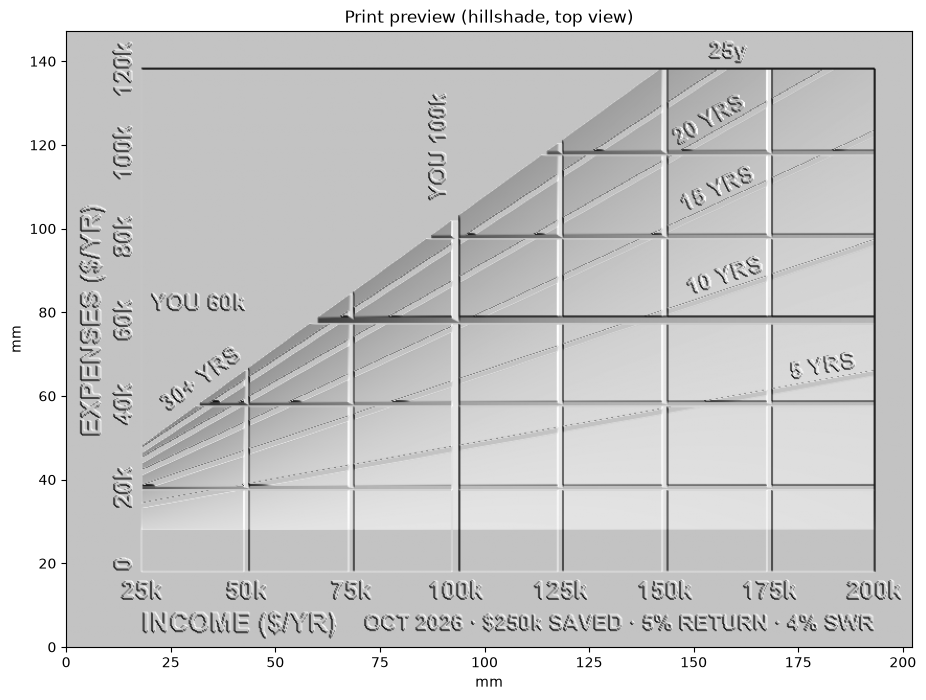

In [8]:
model = build_print_model(PRINT)
skipped = add_labels(model)
if skipped:
    print('No room for these labels (try smaller text or fewer contours):', skipped)

offset = {'deboss': -1, 'emboss': 1}.get(PRINT['text_mode'], 0) * model['p']['text_depth_mm']
verts, tris, _ = heightmap_mesh(model['z_out'], PRINT['cell_mm'], model['text_field'], offset,
                                (model['band_field'], model['band_z']))   # contour shapes traced exactly
closed, volume = check_closed(verts, tris)
assert closed, 'mesh is not watertight'
write_stl(STL_PATH, verts, tris)
ny, nx = model['z'].shape
W, D, H = (nx - 1) * PRINT['cell_mm'], (ny - 1) * PRINT['cell_mm'], verts[:, 2].max()
bx, by, bz = BED_MM
fits = ((W <= bx and D <= by) or (W <= by and D <= bx)) and H <= bz
print(f'{STL_PATH}: {len(tris):,} triangles, {W:.0f} x {D:.0f} x {H:.0f} mm, {volume / 1000:.0f} cm^3, watertight; '
      + (f'fits a {bx} x {by} x {bz} mm printer' if fits else f'TOO BIG for {bx} x {by} x {bz} mm: lower mm_per_10k or height_mm'))

plan = color_plan(model, **COLORS)
if plan:
    start, changes = plan
    print(f'\nColor plan: start with {start}; add a color change (PrusaSlicer layer slider) at:')
    for z, to, why in changes:
        print(f'  Z {z:6.2f} mm -> {to}' + (f'  ({why})' if why else ''))

# Top-down preview of what will print (text cells drawn at their cut/raised height)
fig, ax = plt.subplots(figsize=(13, 8))
z_show = model['z'] + offset * (model['text_field'] >= 0.5)
shade = LightSource(azdeg=315, altdeg=35).hillshade(z_show, vert_exag=2, dx=PRINT['cell_mm'], dy=PRINT['cell_mm'])
ax.imshow(shade, cmap='gray', origin='lower', extent=[0, nx * PRINT['cell_mm'], 0, ny * PRINT['cell_mm']])
ax.set_xlabel('mm'); ax.set_ylabel('mm'); ax.set_title('Print preview (hillshade, top view)')
plt.show()

try:                                   # in Colab, download the STL
    from google.colab import files
    files.download(STL_PATH)
except ImportError:
    pass